# Movie Review Sentiment Binary Prediction

A simple **Bag of words** Nature Language Processing (**NLP**) for determine if a review text is considered positive or negative, **Binary Classification**.
This is a supervised machine learning. Where the **Data** is the review text itself, whereas the **label** is if the review is considered bad or good.

The Essence of how **Bag of Words** works, determine the vocabliry allowed in the bag, then set the number of words repeats in the sentence. Thereby, if a words associated with negative review, it will have a greater weight.  

In [17]:
import random
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score, precision_score

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import Activation, Input

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Data source
data_source_path = "/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"
print("TensorFlow version:", tf.__version__)

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
TensorFlow version: 2.15.0


## Load and Present Example Data 

In [18]:
df=pd.read_csv(data_source_path)

In [19]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


## Setting Variables
main global variables used in the training of the NLP machine learning model

In [21]:
BATCH_SIZE=32
EPOCHS=32
DATA_SPLIT = 0.2

# Learning rate and decay over time
learning_rate: float = 0.001
learning_decay_step: int = 1100
learning_decay_rate: float = 0.97

#
max_vocab_len = 200000
sequence_length = 300

# Number of weights.
embedding_dim = 128

## Extract and Setup Data
Extract the data from the Pandas frame for the Data and Label, split between Training and Test/validation Data.


In [22]:
# Extract the data and prediction label data
quanitity_classes = ['review']
X_data = df[quanitity_classes]
y_data = df['sentiment']
labels = y_data.unique()

# Convert to numpy object and convert the categorical to int code
texts = np.array(X_data)
label_data = np.array(pd.Categorical(df['sentiment']).codes).astype('int')

# Split data to training data and validation/test data.
X_train, X_val, y_train, y_val = train_test_split(texts, label_data, test_size=DATA_SPLIT, random_state=42)

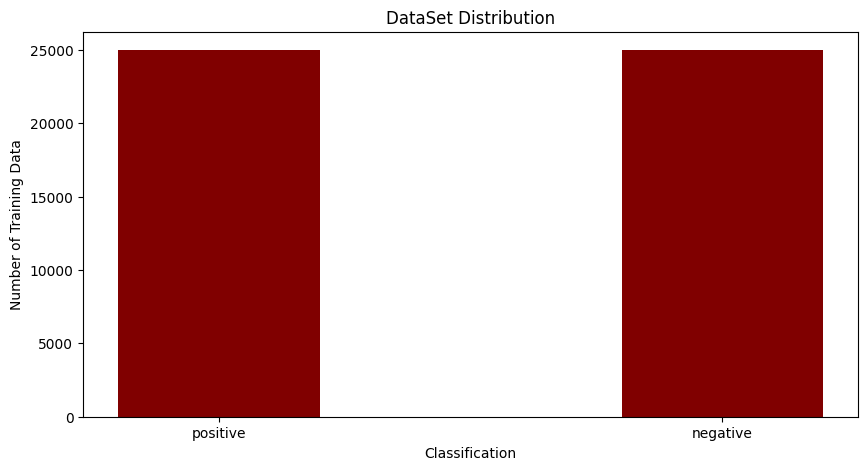

In [23]:
# Compute quantative of each categorical.
train_clf_count = [y_data.value_counts()[l] for l in labels]

fig = plt.figure(figsize = (10, 5))
plt.bar(labels, train_clf_count, color ='maroon', 
        width = 0.4)
plt.xlabel("Classification")
plt.ylabel("Number of Training Data")
plt.title("DataSet Distribution")
plt.show()

## Tokenize the Text

Before the data can be used in the Model, the data has to be tokenize in order to be used in the model. Given that the model itself can not run on strings. Rather it has to be quantized with some kind of numerical representation.

In [24]:
#
vectorize_layer = TextVectorization(
    standardize="lower_and_strip_punctuation",
    split = 'whitespace',
    max_tokens=max_vocab_len,
    ngrams = None,
    output_mode='int',
    pad_to_max_tokens = True, vocabulary = None,
    output_sequence_length=sequence_length)

# Calculate vocabulary size 
vectorize_layer.adapt(data=texts, batch_size=BATCH_SIZE)

# Extract the vocabulary extracted from adapting to the whole training data.
vocab = vectorize_layer.get_vocabulary()
vocab_size = len(vocab)

print("Vocab Size {0}".format(vocab_size))

Vocab Size 182738


In [25]:
random_sentence = random.choice(texts)
print(f"original text : \n {random_sentence} \n\n Vectorized format : \n{vectorize_layer([random_sentence])} \n\n shape : {vectorize_layer([random_sentence]).shape}")

original text : 
 ['Never, ever, have I been as impressed by a film as this little piece about four groups of people, that faces a crisis, or many. In some ways a little like Short Cuts, but totally different, at the same time.<br /><br />There are a heap of lead characters, whom we all learn to know very well as their stories unfold, and they are, as persons show their good and their bad sides, their weaknesses and their strengths, with lots of drama and laughter.<br /><br />The closest equivalent in a US movie, I can think of, which then is far weaker in every respect, is the Royal Tenenbaums. <br /><br />Four Shades of Brown, as the title would be in English, tells the story about a stressed out hotelier and his wife, and his elderly parents (who are traveling magicians); about the receptionist at an animal crematory and his family misadventures; about the members of a cooking course (who mostly talk about their sorry lives) and fourthly about the funeral for a womanizing trotter jo

In [26]:
# Create the machine learning model.
model = Sequential([
  Input(shape = (1,), dtype = tf.string),
  vectorize_layer,
  Embedding(input_dim=vocab_size, output_dim=embedding_dim, embeddings_initializer= 'uniform', name="embedding"),
  GlobalAveragePooling1D(),
  Dense(48, activation='relu'),
  Dense(16, activation='relu'),
  Dense(1),
  Activation('sigmoid') # Comment out if from_logits is True in the BinaryCrossentropy
])

# 
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    learning_rate,
    decay_steps=learning_decay_step,
    decay_rate=learning_decay_rate,
    staircase=False)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, beta_1=0.5, beta_2=0.9)
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=['accuracy',tf.metrics.BinaryAccuracy(threshold=0.5)])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 300, 128)       │    23,390,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 48)             │         6,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,397,457 (89.25 MB)

 Trainable params: 23,397,457 (89.25 MB)

 Non-trainable params: 0 (0.00 B)

## Training Model
Training the model with validation data. This allow to see how its performance of data it has never been exposed for each Epoch.

In [27]:
#
training_result = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=( X_val,  y_val), verbose=1)

Epoch 1/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6991 - binary_accuracy: 0.6991 - loss: 0.5436 - val_accuracy: 0.7915 - val_binary_accuracy: 0.7915 - val_loss: 0.4249
Epoch 2/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9006 - binary_accuracy: 0.9006 - loss: 0.2482 - val_accuracy: 0.8968 - val_binary_accuracy: 0.8968 - val_loss: 0.2570
Epoch 3/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9318 - binary_accuracy: 0.9318 - loss: 0.1802 - val_accuracy: 0.8996 - val_binary_accuracy: 0.8996 - val_loss: 0.2566
Epoch 4/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9537 - binary_accuracy: 0.9537 - loss: 0.1282 - val_accuracy: 0.8036 - val_binary_accuracy: 0.8036 - val_loss: 0.4260
Epoch 5/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9594 - binary_accuracy: 0.9594 - loss: 0.1124 - val_accuracy: 0.8736 - val_binary_accuracy: 0.8736 - val_loss: 0.3461
Epoch 6/32
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - ac

# Performance
The following is to show how good the trained model is at predicting if a review is considered good or bad review.

In [28]:
loss, accuracy, binary_accuracy = model.evaluate(X_val, y_val,batch_size=BATCH_SIZE)

print("Loss: ", loss)
print("Accuracy: ", accuracy)
print("Binary Accuracy: ", binary_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8767 - binary_accuracy: 0.8767 - loss: 0.8622
Loss:  0.8637880086898804
Accuracy:  0.8781999945640564
Binary Accuracy:  0.8781999945640564


## Plotting Training History
By looking at the training history, it can give indication if a model is overfitted/underfitted and etc.

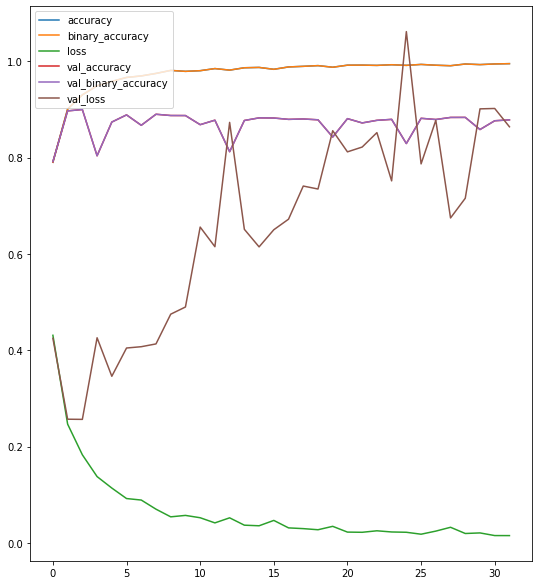

In [29]:
def plotTrainingHistory(result_collection, loss_label="", val_label="", title="", x_label="", y_label=""):
    fig = plt.figure(figsize=(len(result_collection) * 1.5, 10), dpi=72)

    for i, result_key in enumerate(result_collection.keys()):
        dataplot = result_collection[result_key]
        plt.plot(dataplot, label=result_key)
        plt.ylabel(ylabel=y_label)
        plt.xlabel(xlabel=x_label)
        plt.legend(loc="upper left")
    return fig

plotTrainingHistory(training_result.history, loss_label="", val_label="", x_label="", y_label="")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


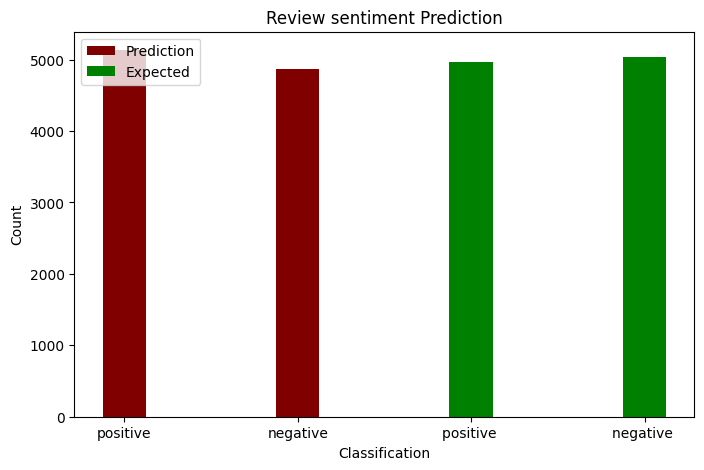

In [30]:
predictions = model.predict(X_val)

fig = plt.figure(figsize = (8, 5))

# creating the bar plot
prediction_classifiction = [pred > 0.5 for pred in predictions]
_, expected_classificiton =  np.unique(y_val, return_counts=True)
width = 0.25  # the width of the bars

plt.bar(labels, [prediction_classifiction.count(0), prediction_classifiction.count(1)], color ='maroon', width = width, align='center', label='Prediction')
plt.bar(labels + " ", expected_classificiton, color ='green', width = width, align='center', label='Expected')
plt.legend(loc="upper left")

plt.xlabel("Classification")
plt.ylabel("Count")
plt.title("Review sentiment Prediction")
plt.show()

## Confusion Matrix
Shows how good the model performance in various aspect.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Recall 0.8783267573999202
F1 0.8781892368009637
Precision 0.8785716021227981


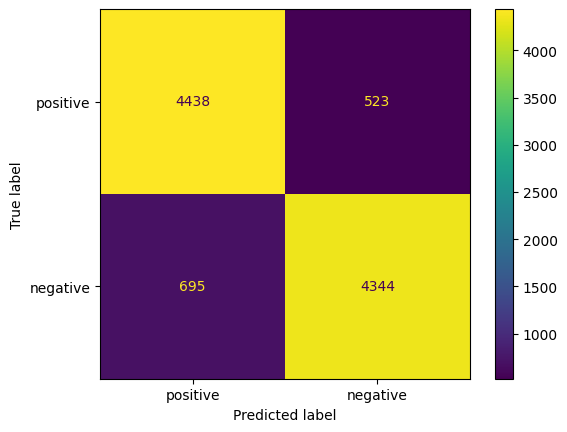

In [31]:
predictions = np.rint(model.predict(X_val)).astype('int').flatten()

cm = confusion_matrix(y_val, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=labels)
disp.plot()

recall = recall_score(y_val, predictions, average='macro')
f1 = f1_score(y_val, predictions, average='macro')
precision = precision_score(y_val, predictions, average='macro')
print("Recall {}".format(recall))
print("F1 {}".format(f1))
print("Precision {}".format(precision))